In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/netflix-data-analytics-project/netflix_data.csv


In [2]:
import pandas as pd

# Replace the path below with the one you just copied
df = pd.read_csv("/kaggle/input/netflix-data-analytics-project/netflix_data.csv")

# Look at first 5 rows
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


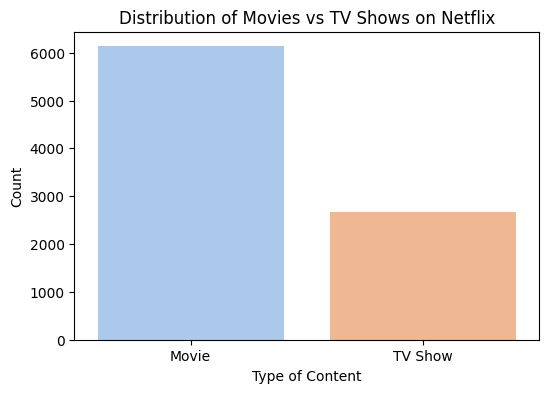

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# Count of Movies vs TV Shows
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='type', palette='pastel')
plt.title("Distribution of Movies vs TV Shows on Netflix")
plt.xlabel("Type of Content")
plt.ylabel("Count")
plt.show()


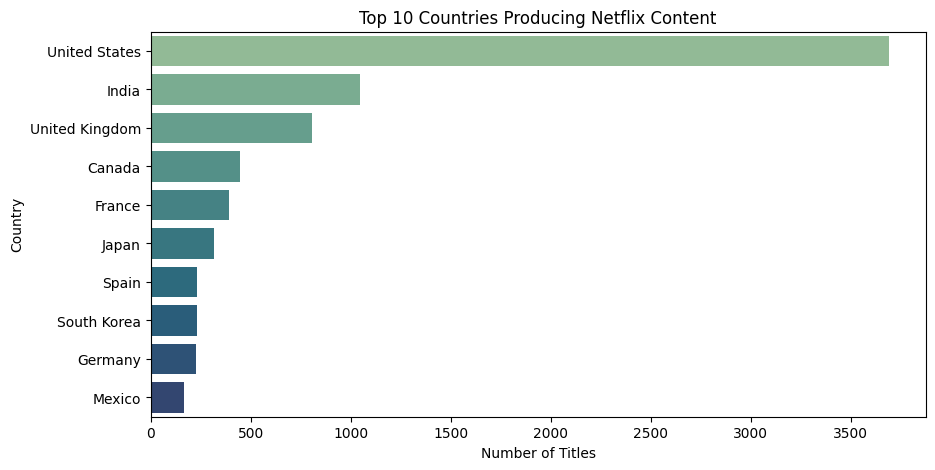

In [4]:
# Remove nulls in country column
df_country = df.dropna(subset=['country'])

# Split multiple countries and count each separately
country_series = df_country['country'].str.split(', ').explode()
top_countries = country_series.value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='crest')
plt.title("Top 10 Countries Producing Netflix Content")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.show()


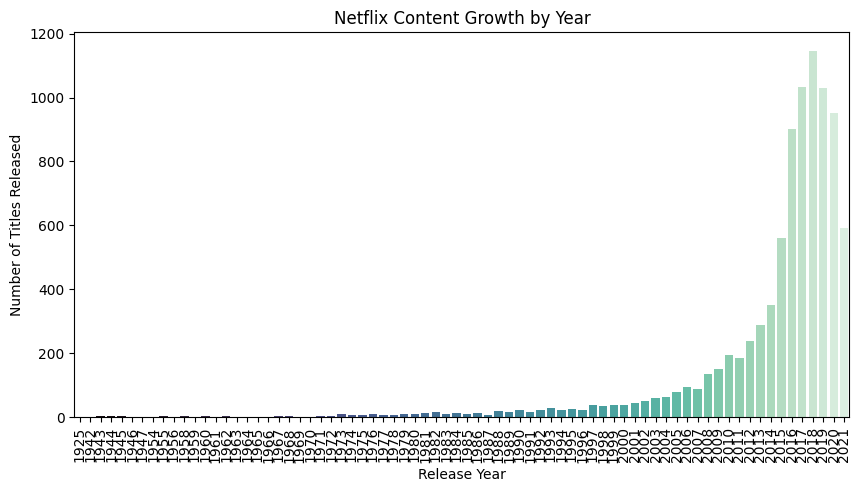

In [5]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='release_year', palette='mako', order=sorted(df['release_year'].unique()))
plt.title("Netflix Content Growth by Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles Released")
plt.xticks(rotation=90)
plt.show()


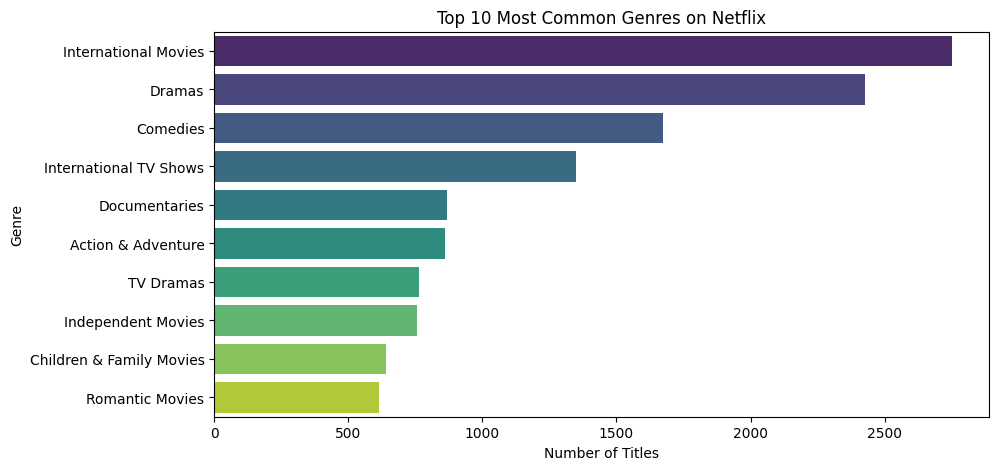

In [6]:
# Genres are in 'listed_in' column
genres = df['listed_in'].dropna().str.split(', ').explode().value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=genres.values, y=genres.index, palette='viridis')
plt.title("Top 10 Most Common Genres on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.show()


In [7]:
# Separate numeric value from the 'duration' column
df['duration_num'] = df['duration'].str.extract('(\d+)').astype(float)

# Check the average duration for each type
avg_duration = df.groupby('type')['duration_num'].mean()
avg_duration


type
Movie      99.577187
TV Show     1.764948
Name: duration_num, dtype: float64

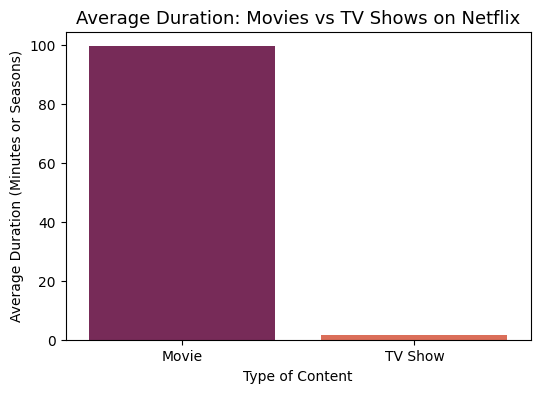

In [8]:
plt.figure(figsize=(6,4))
sns.barplot(x=avg_duration.index, y=avg_duration.values, palette='rocket')
plt.title("Average Duration: Movies vs TV Shows on Netflix", fontsize=13)
plt.xlabel("Type of Content")
plt.ylabel("Average Duration (Minutes or Seasons)")
plt.show()


### Additional Insight
- Movies on Netflix average around 100 minutes in length.
- TV shows typically run for 1–2 seasons on average.
- This indicates Netflix maintains shorter, binge-friendly content formats.
- Movies on Netflix average about 100 minutes, while TV Shows tend to run for 1–2 seasons.  
- This reflects Netflix’s strategy of offering quick, bingeable content for both casual and committed viewers.